# 2. Content-Based Recommender

Se evaluó un recomendador basado en contenido que utiliza una matriz de similitud coseno precomputada a partir de embeddings de sentence-transformers (`all-mpnet-base-v2`, 768 dimensiones). La matriz original de 5,000×5,000 películas se construyó en el pipeline de preprocesamiento; para este benchmark se extrajo la submatriz correspondiente a las ~3,800 películas del dataset.

### ¿Cómo funciona el modelo?

El `ContentBasedRecommender` genera recomendaciones en tres pasos:

1. **Selección de películas favoritas**: se toman las películas mejor calificadas del usuario en el train (rating ≥ 3.5, hasta 10 películas, si tiene más se seleccionan las que calificó más recientemente)
2. **Rating-weighted**: para cada película favorita del usuario se calcula su similitud con las películas que el usuario no ha visto. Después se recomiendan las *k* películas con mayor simlitud a las favoritas del usuario, lo que evita la dilución de señal cuando el usuario tiene gustos diversos.
3. **Popularity blend**: al score de contenido se le suma una pequeña señal de popularidad (`score_final = (1−α) × contenido + α × popularidad`), que rompe empates a favor de películas más conocidas sin sacrificar la personalización.

No hay aprendizaje iterativo ni gradientes — todo el "modelo" vive en la matriz de similitud precomputada más la señal de popularidad del catálogo.

In [2]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent))

import numpy as np
import pandas as pd
import ml.config as cfg
from ml.evaluation.splits import movielens_split
from ml.evaluation.splits import survey_split_sampled
from ml.evaluation.notebook_utils import evaluate_movielens, plot_dataset_metrics
from ml.models.content_based import ContentBasedRecommender
from ml.evaluation.notebook_utils import (
    evaluate_survey, print_metrics, plot_survey_metrics,
    RATINGS_SURVEY_PATH,
)
from IPython.display import Markdown, display
from tabulate import tabulate

K = 10


## Evaluación sobre el dataset de Benchmark

Se utilizó el mismo split temporal 80/20 del notebook 1 (Popularity). El modelo se entrenó sobre el train y se evaluó con **full-catalog ranking** sobre las ~3,800 películas del catálogo, midiendo las *Precision, Recall, NDCG, Diversity, Novelty y Coverage*.

train=797,809  test=108,298  N_ITEMS=3830  cosine_sim=(3830, 3830)

╒════════════════════╤═══════════╕
│ Métrica            │     Valor │
╞════════════════════╪═══════════╡
│ Precision@K        │    0.0922 │
├────────────────────┼───────────┤
│ Recall@K (norm)    │    0.0968 │
├────────────────────┼───────────┤
│ NDCG@K             │    0.1194 │
├────────────────────┼───────────┤
│ Diversity@K        │    0.3605 │
├────────────────────┼───────────┤
│ Novelty@K          │    0.5161 │
├────────────────────┼───────────┤
│ Coverage           │    0.4601 │
├────────────────────┼───────────┤
│ Usuarios evaluados │ 5986      │
├────────────────────┼───────────┤
│ Usuarios omitidos  │    1      │
╘════════════════════╧═══════════╛


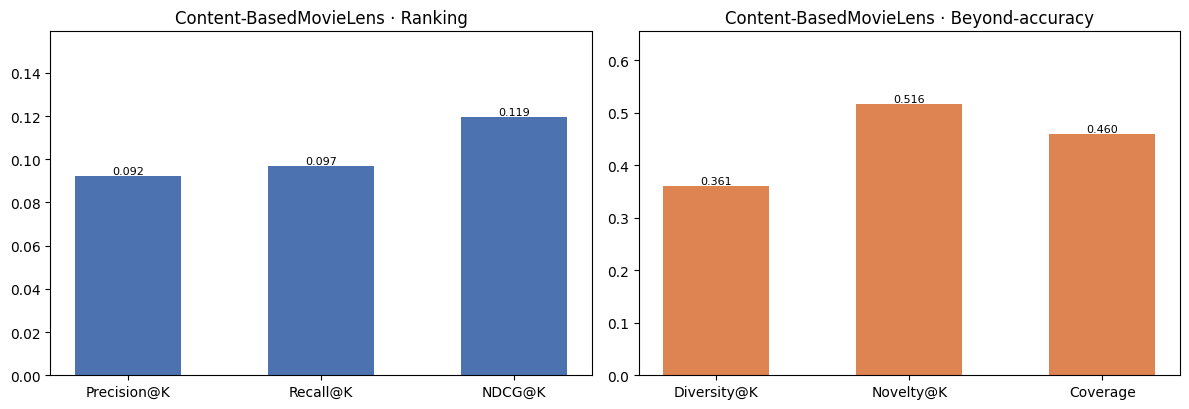

In [3]:
train, test = movielens_split(cfg.RATINGS_PATH)
cosine_sim = cfg.load_cosine_sim()
popularity = cfg.load_popularity()
N_ITEMS = cfg.catalog_size()
print(f"train={len(train):,}  test={len(test):,}  N_ITEMS={N_ITEMS}  cosine_sim={cosine_sim.shape}")

model = ContentBasedRecommender(
    cosine_sim_path=cfg.COSINE_SIM_PATH,
    movies_path=cfg.MOVIES_PATH,
    cosine_sim=cosine_sim,
)
results = evaluate_movielens(model, train, test, K, cosine_sim, popularity, N_ITEMS)

# Tabla de métricas
metric_keys = ['precision', 'recall', 'ndcg', 'diversity', 'novelty', 'coverage']
metric_names = ['Precision@K', 'Recall@K (norm)', 'NDCG@K', 'Diversity@K', 'Novelty@K', 'Coverage']
rows = [[name, f"{results[key]:.4f}"] for key, name in zip(metric_keys, metric_names)]
rows.append(['Usuarios evaluados', f"{results['n_evaluated']:,}"])
rows.append(['Usuarios omitidos', f"{results['n_skipped']:,}"])
print()
print(tabulate(rows, headers=['Métrica', 'Valor'], tablefmt='fancy_grid'))

plot_dataset_metrics(movielens=results, title_prefix="Content-Based")

## Evaluación sobre el dataset de Survey (sampled LOO)

Se evaluó el modelo content-based sobre los ~125 usuarios reales del Survey con el protocolo **leave-one-out sampled** (1 positivo + 99 negativos aleatorios por fold). Se midieron **HR@K** y **NDCG@K**.

Se utilizó sampled evaluation en lugar de full-catalog porque los usuarios de Survey solo interactuaron con ~87 películas del catálogo de ~3,800. En full-catalog, el modelo tendría que rankear ~3,700 películas que nunca aparecieron en el train de Survey, lo que distorsionaría las métricas. Sampled evaluation nivela la comparación entre modelos.

El train de cada fold incluyó **todos los ratings de todos los usuarios válidos** (no solo los del usuario evaluado), preservando la matriz completa de interacciones.

Survey folds: 118


### Métricas Survey — K=10

╒═════════════╤═════════╕
│ Métrica     │   Valor │
╞═════════════╪═════════╡
│ hr          │   0.636 │
├─────────────┼─────────┤
│ ndcg        │   0.426 │
├─────────────┼─────────┤
│ n_evaluated │ 118     │
├─────────────┼─────────┤
│ n_skipped   │   0     │
╘═════════════╧═════════╛


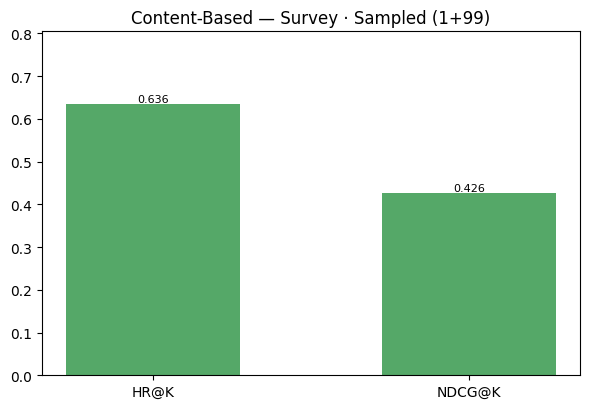

In [4]:
sv_folds = survey_split_sampled(
    RATINGS_SURVEY_PATH, cfg.MOVIES_PATH, n_negatives=99, seed=42,
)
print(f"Survey folds: {len(sv_folds)}")

survey_results = evaluate_survey(
    model_factory=lambda: ContentBasedRecommender(
        cosine_sim_path=cfg.COSINE_SIM_PATH,
        movies_path=cfg.MOVIES_PATH,
        cosine_sim=cosine_sim,
    ),
    folds=sv_folds,
    k=K,
    n_items=N_ITEMS,
)
display(Markdown(f'### Métricas Survey — K={K}'))
print_metrics(survey_results)
plot_survey_metrics(survey_results, title_prefix='Content-Based — ')

## Ejemplos de recomendaciones

Se mostraron las top-10 recomendaciones del modelo content-based para los mismos 3 usuarios aleatorios (seed=42) que en el notebook de Popularity, para permitir una comparación directa. A diferencia de Popularity (que recomienda la misma lista a todos), Content-Based produce listas distintas que reflejan el perfil de cada usuario.

In [5]:
movies_df = pd.read_csv(cfg.MOVIES_PATH)
lookup = {int(r.movie_id): (r.title, str(r.release_date)[:4] if pd.notna(getattr(r, 'release_date', None)) else '—')
          for r in movies_df.itertuples(index=False)}

rng_ex = np.random.default_rng(42)
sample_users = rng_ex.choice(test['user_id'].unique(), size=3, replace=False).tolist()

for uid in sample_users:
    display(Markdown(f'### Usuario {uid}'))

    # Top-5 películas favoritas del usuario en train
    user_train = train[train['user_id'] == uid].sort_values('rating', ascending=False).head(5)
    fav_rows = []
    for rank, row in enumerate(user_train.itertuples(index=False), 1):
        title, year = lookup.get(int(row.movie_idx), (f'<idx {row.movie_idx}>', '—'))
        fav_rows.append([rank, title, year, f'{row.rating:.1f}'])
    display(Markdown('**Top-5 películas favoritas (en train):**'))
    print(tabulate(fav_rows, headers=['#', 'Título', 'Año', 'Rating'], tablefmt='fancy_grid'))

    # Top-10 recomendaciones del modelo
    recs = model.recommend(int(uid), n=K)
    rec_rows = []
    for rank, mid in enumerate(recs, 1):
        title, year = lookup.get(int(mid), (f'<idx {mid}>', '—'))
        rec_rows.append([rank, title, year])
    display(Markdown(f'**Top-{K} recomendaciones del modelo:**'))
    print(tabulate(rec_rows, headers=['#', 'Título', 'Año'], tablefmt='fancy_grid'))
    print()


### Usuario 3927

**Top-5 películas favoritas (en train):**

╒═════╤═══════════════════════════════════════╤═══════╤══════════╕
│   # │ Título                                │   Año │   Rating │
╞═════╪═══════════════════════════════════════╪═══════╪══════════╡
│   1 │ The Way Way Back                      │  2013 │        5 │
├─────┼───────────────────────────────────────┼───────┼──────────┤
│   2 │ Bridesmaids                           │  2011 │        5 │
├─────┼───────────────────────────────────────┼───────┼──────────┤
│   3 │ Ocean's Thirteen                      │  2007 │        5 │
├─────┼───────────────────────────────────────┼───────┼──────────┤
│   4 │ Anchorman: The Legend of Ron Burgundy │  2004 │        5 │
├─────┼───────────────────────────────────────┼───────┼──────────┤
│   5 │ National Treasure: Book of Secrets    │  2007 │        5 │
╘═════╧═══════════════════════════════════════╧═══════╧══════════╛


**Top-10 recomendaciones del modelo:**

╒═════╤════════════════════════════════╤═══════╕
│   # │ Título                         │   Año │
╞═════╪════════════════════════════════╪═══════╡
│   1 │ Zombieland: Double Tap         │  2019 │
├─────┼────────────────────────────────┼───────┤
│   2 │ Toy Story 4                    │  2019 │
├─────┼────────────────────────────────┼───────┤
│   3 │ Jurassic World Dominion        │  2022 │
├─────┼────────────────────────────────┼───────┤
│   4 │ Jurassic World: Fallen Kingdom │  2018 │
├─────┼────────────────────────────────┼───────┤
│   5 │ Spy                            │  2015 │
├─────┼────────────────────────────────┼───────┤
│   6 │ Heat                           │  1995 │
├─────┼────────────────────────────────┼───────┤
│   7 │ Stuck in Love                  │  2013 │
├─────┼────────────────────────────────┼───────┤
│   8 │ The Wedding Date               │  2005 │
├─────┼────────────────────────────────┼───────┤
│   9 │ The Lost World: Jurassic Park  │  1997 │
├─────┼─────────────

...

### Usuario 4641

**Top-5 películas favoritas (en train):**

╒═════╤════════════════════════════════╤═══════╤══════════╕
│   # │ Título                         │   Año │   Rating │
╞═════╪════════════════════════════════╪═══════╪══════════╡
│   1 │ The Matrix                     │  1999 │        5 │
├─────┼────────────────────────────────┼───────┼──────────┤
│   2 │ The Dawn Wall                  │  2017 │        5 │
├─────┼────────────────────────────────┼───────┼──────────┤
│   3 │ Parasite                       │  2019 │        5 │
├─────┼────────────────────────────────┼───────┼──────────┤
│   4 │ La Maison en Petits Cubes      │  2008 │        5 │
├─────┼────────────────────────────────┼───────┼──────────┤
│   5 │ Guardians of the Galaxy Vol. 2 │  2017 │        5 │
╘═════╧════════════════════════════════╧═══════╧══════════╛


**Top-10 recomendaciones del modelo:**

╒═════╤═════════════════════════════════════════════╤═══════╕
│   # │ Título                                      │   Año │
╞═════╪═════════════════════════════════════════════╪═══════╡
│   1 │ John Wick: Chapter 2                        │  2017 │
├─────┼─────────────────────────────────────────────┼───────┤
│   2 │ John Wick: Chapter 3 - Parabellum           │  2019 │
├─────┼─────────────────────────────────────────────┼───────┤
│   3 │ John Wick: Chapter 4                        │  2023 │
├─────┼─────────────────────────────────────────────┼───────┤
│   4 │ The Matrix Resurrections                    │  2021 │
├─────┼─────────────────────────────────────────────┼───────┤
│   5 │ Avengers: Infinity War                      │  2018 │
├─────┼─────────────────────────────────────────────┼───────┤
│   6 │ Memories of Murder                          │  2003 │
├─────┼─────────────────────────────────────────────┼───────┤
│   7 │ The Guardians of the Galaxy Holiday Special │  2022 │
├─────┼─

## Conclusiones

Si bien las métricas de ranking (Precision, Recall, NDCG) del modelo Content-Based resultaron ligeramente inferiores a las del baseline de Popularity, las métricas **beyond-accuracy** mostraron una mejora sustancial:

- **Novelty** (~0.52 vs ~0.10 de Popularity): el modelo recomienda películas que el usuario difícilmente encontraría por sí solo, en lugar de limitarse a los blockbusters que todos conocen. Esto es precisamente el valor agregado de un sistema de recomendación — descubrir contenido relevante pero poco conocido.
- **Coverage** (46% vs 1.3% de Popularity): el modelo explora casi la mitad del catálogo a través de las recomendaciones de los ~6,000 usuarios, frente al ~1% que Popularity repite a todos. Esto indica que Content-Based aprovecha la diversidad del catálogo en lugar de concentrarse en un puñado de películas populares.
- **Diversity** (~0.36 vs ~0.43 de Popularity): fue la única métrica beyond-accuracy donde Content-Based quedó por debajo. Esto es esperable y coherente con el diseño del modelo: al recomendar películas **similares** a las que el usuario ya disfrutó, las listas tienden a ser temáticamente homogéneas (por ejemplo, si al usuario le gustan los thrillers, el top-10 estará dominado por thrillers). 

En resumen, Content-Based sacrificó una pequeña fracción de precisión en ranking a cambio de una capacidad de exploración y descubrimiento radicalmente superior. Para un sistema de recomendación real, este balance es deseable: no basta con acertar — hay que acertar con películas que el usuario no habría encontrado por su cuenta.

## Persistencia del modelo

Content-Based no requiere un archivo `.save()` separado porque su artefacto principal (`cosine_sim_benchmark.npy`) ya se encuentra en disco. Se guardaron los hiperparámetros en un archivo JSON para poder reconstruir el modelo en notebooks posteriores sin ambigüedad.

In [6]:
import json as _json
from pathlib import Path

SAVED_DIR = Path('..') / 'models' / 'saved'
SAVED_DIR.mkdir(parents=True, exist_ok=True)

meta = {
    'model': 'ContentBasedRecommender',
    'cosine_sim_path': str(cfg.COSINE_SIM_PATH),
    'movies_path': str(cfg.MOVIES_PATH),
    'hyperparameters': {
        'positive_threshold': model._positive_threshold,
        'top_seed_movies': model._top_seed_movies,
        'popularity_alpha': model._popularity_alpha,
        'beta': model._beta,
    },
}
with open(SAVED_DIR / 'content_based_meta.json', 'w') as f:
    _json.dump(meta, f, indent=2)
print(f'Metadatos guardados en: {SAVED_DIR / "content_based_meta.json"}')

Metadatos guardados en: ../models/saved/content_based_meta.json
